##### Process scref

In [1]:
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scanpy as sc

# import sys
# sys.path.append('../src')
# from utils import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
ad_sc = sc.read('/data1/hounaiqiao/wzr/DATA/lhy/brca/sc/tnbc_sc.h5ad')
ad_st = sc.read('/data1/hounaiqiao/wzr/Simulated_Xenium/brca_rep1/w100/simulated_square_spot_data.h5ad')

In [3]:
# QC

ad_sc.var['mt'] = ad_sc.var_names.str.startswith(('MT-', 'mt-', 'Mt-'))
sc.pp.calculate_qc_metrics(ad_sc, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
# sc.pl.violin(ad_sc, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], rotation=90)
ad_sc = ad_sc[ad_sc.obs.total_counts <= 100000, :]
sc.pp.filter_genes(ad_sc, min_cells=5)
sc.pp.filter_cells(ad_sc, min_genes=300)
# sc.pl.violin(ad_sc, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], rotation=90)

In [5]:
ad_sc.write_h5ad('/data1/hounaiqiao/wzr/DATA/lhy/brca/sc/tnbc_sc_pp.h5ad')

<Axes:title={'center':'pct counts mt'}, xlabel='total_counts', ylabel='n_genes_by_counts'>

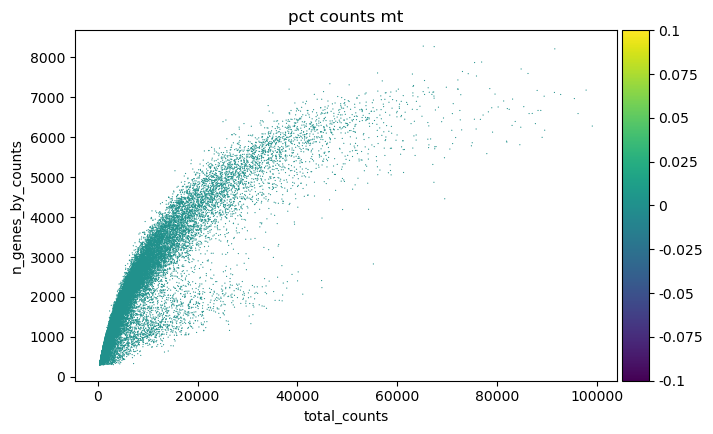

In [7]:
sc.pl.scatter(ad_sc, "total_counts", "n_genes_by_counts", color="pct_counts_mt",show=False)

In [7]:
ad_st.uns['spatial']['Xenium_BRCA']['scalefactors']['spot_diameter_fullres'] = 55 / 0.2125

In [4]:
ad_st.uns['spatial']['Xenium_BRCA']['scalefactors']
# ad_st.write_h5ad('/root/spatiocell/data/Simulated_Xenium/brca_rep1/w55/simulated_data.h5ad')

{'spot_diameter_fullres': np.float64(258.8235294117647),
 'spot_diameter_fulres': np.float64(258.8235294117647),
 'tissue_hires_scalef': np.float64(0.5),
 'tissue_lowres_scalef': np.float64(0.1)}

In [5]:
cell_type_column = 'label'  # specify the column name for cell type annotations in ad_sc.obs

ad_sc.raw = ad_sc.copy()
sc.pp.normalize_total(ad_sc,target_sum=2000)

sc.pp.highly_variable_genes(ad_sc, flavor='seurat_v3',n_top_genes=1000)
sc.tl.rank_genes_groups(ad_sc, groupby=cell_type_column, method='wilcoxon')
markers_df = pd.DataFrame(ad_sc.uns["rank_genes_groups"]["names"]).iloc[0:100, :]
markers = list(np.unique(markers_df.melt().value.values))
markers = list(set(ad_sc.var.loc[ad_sc.var['highly_variable']==1].index)|set(markers)) # highly variable genes + cell type marker genes

In [ ]:
ad_sc.var.loc[ad_sc.var.index.isin(markers),'Marker'] = True
ad_sc.var['Marker'] = ad_sc.var['Marker'].fillna(False)
ad_sc.var['highly_variable'] = ad_sc.var['Marker']

sc.pp.log1p(ad_sc)
sc.pp.pca(ad_sc,svd_solver='arpack', n_comps=30, use_highly_variable=True)

ad_sc.X.max()

In [ ]:
sc.pp.neighbors(ad_sc, metric='cosine', n_neighbors=30, n_pcs = 30)
sc.tl.umap(ad_sc, min_dist = 0.5, spread = 1, maxiter=60)

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
sc.pl.umap(
    ad_sc, color=cell_type_column, size=15, frameon=False, show=False, ax=axs,legend_loc='on data'
)
plt.tight_layout()

In [ ]:
ad_sc.write('/root/spatiocell/benchmarks/deconvolution_mapping/results/spatialscope/Ckpts_scRefs/brca/Ref.h5ad')

##### Deconvolution

In [ ]:
!cd /root/spatiocell/SpatialScope

!python ./src/Nuclei_Segmentation.py --tissue brca --out_dir  /root/spatiocell/benchmarks/deconvolution_mapping/results/spatialscope  --ST_Data  /root/spatiocell/data/Simulated_Xenium/brca_rep1/w55/simulated_data.h5ad --Img_Data  /root/spatiocell/data/Simulated_Xenium/brca_rep1/HE_aligned/align_he.png

!python ./src/Cell_Type_Identification.py --tissue brca --out_dir  /data1/hounaiqiao/wzr/benchmarks/deconvolution_mapping/result/spatialscope/  --ST_Data /data1/hounaiqiao/wzr/benchmarks/deconvolution_mapping/result/spatialscope/brca/sp_adata_ns.h5ad --SC_Data /data1/hounaiqiao/wzr/DATA/lhy/brca/sc/tnbc_sc_pp.h5ad --cell_class_column label

In [5]:
# 检查模拟空转spot之间的距离

adata_st = sc.read_h5ad('/root/spatiocell/data/Simulated_Xenium/brca_rep1/w55/simulated_data.h5ad')
adata_st

AnnData object with n_obs × n_vars = 10594 × 313
    obs: 'x', 'y', 'x_pixel', 'y_pixel', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'IRF7+_DCs', 'Invasive_Tumor', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'cell_count'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [10]:
adata_st.uns['spatial']['Xenium_BRCA']['scalefactors']

{'spot_diameter_fullres': 258.8235294117647,
 'tissue_hires_scalef': 0.5,
 'tissue_lowres_scalef': 0.1}

In [14]:
loc_df = adata_st.obs[['x','y','x_pixel','y_pixel']]

# 选择同一行的两个相邻 spot
row_y = 10  # 选择某一行

# 获取这一行的所有 spot，按 x 坐标排序
same_row = loc_df[loc_df['y'] == row_y].sort_values('x')

if len(same_row) >= 2:
    # 取前两个相邻的 spot
    spot1 = same_row.iloc[4]
    spot2 = same_row.iloc[5]
    
    distance = spot2['x_pixel'] - spot1['x_pixel']
    print(f"Row {row_y}: Spot x={spot1['x']} to x={spot2['x']}")
    print(f"Pixel distance: {distance:.2f}")
else:
    print(f"Row {row_y} doesn't have enough spots")

Row 10: Spot x=4.0 to x=5.0
Pixel distance: 258.82


In [6]:
sp = sc.read_h5ad('/data1/hounaiqiao/yy/NucleiSeg/benchmark_review/interval/results/luca_w55/spatialscope/cell_types/sp_adata.h5ad')

In [5]:
ct_df = pd.read_csv('/data1/hounaiqiao/yy/NucleiSeg/benchmark_review/interval/results/brca_rep1_w100/spatialscope/cell_types/CellTypeLabel_nu10.csv',
                    index_col = 0)

spot_ct_counts = (
    ct_df.groupby(["spot_index", "discrete_label_ct"])
      .size()
      .unstack(fill_value=0)
      .astype(int)
)
spot_ct_counts.head()

discrete_label_ct,B-cells,Dendritic,Endothelial,Fibroblast,Macrophage,Myeloid,Neoplasm,Normal Epithelial,Perivascular-Like,T Cells
spot_index,,,,,,,,,,
53,0,0,20,2,1,0,30,0,1,1
55,0,0,1,2,4,0,93,0,0,0
57,0,0,10,5,6,0,37,1,0,1
59,0,0,4,3,4,0,49,1,0,3
61,1,0,8,6,5,0,38,0,0,3


In [6]:
spot_ct_counts

discrete_label_ct,B-cells,Dendritic,Endothelial,Fibroblast,Macrophage,Myeloid,Neoplasm,Normal Epithelial,Perivascular-Like,T Cells
spot_index,,,,,,,,,,
53,0,0,20,2,1,0,30,0,1,1
55,0,0,1,2,4,0,93,0,0,0
57,0,0,10,5,6,0,37,1,0,1
59,0,0,4,3,4,0,49,1,0,3
61,1,0,8,6,5,0,38,0,0,3
...,...,...,...,...,...,...,...,...,...,...
3393,1,0,3,8,1,0,0,18,0,0
3395,0,0,0,0,1,0,11,1,0,0
3396,0,0,0,1,0,2,0,2,0,0


In [7]:
spot_ct_counts.to_csv('/data1/hounaiqiao/wzr/benchmarks/spatiocell/deconv_res/brca_rep1/spot100/spatialscope.csv')